# Proyecto Integrado III — Evidencia de Aprendizaje 2
## Limpieza y Transformación de Datos | Dataset: Telco Customer Churn

| | |
|---|---|
| **Asignatura** | Proyecto Integrado III |
| **Docente** | Andrés Felipe Palacio |
| **Integrantes** | Robinson Marin Morales · Guillermo León Loaiza Mesa · Jaider Morales Bautista · Aleicer Vesga Rueda |
| **Fecha** | 11/05/2026 |


---
# I. Descripción de Necesidades de Limpieza

Antes de modificar el dataset realizamos un análisis detallado de cada dimensión de calidad, apoyándonos en los hallazgos del Avance 1 (ydata-profiling) y en una inspección adicional del DataFrame ya renombrado.


## 1.1 Duplicados

**Hallazgo:** El dataset **no contiene filas duplicadas**. Cada registro está identificado de manera única por `id_cliente`. Esto fue confirmado en el Avance 1 mediante `df.duplicated().sum()` → 0.

**Acción requerida:** Ninguna. Se ejecutará `drop_duplicates()` de forma preventiva para documentar el proceso y garantizar que futuros cruces de datos no introduzcan duplicados.


## 1.2 Valores Nulos

| Columna | Nulos | % sobre 7 043 | Causa |
|---------|------:|------:|-------|
| `cargo_total` | 11 | 0.16 % | Clientes con `meses_permanencia = 0`; aún no generaron cargos acumulados |

**Hallazgo:** La columna `cargo_total` fue importada como `object` porque los 11 registros de clientes nuevos tienen un espacio en blanco `" "` en lugar de un valor numérico. Al convertirla a `float64` con `pd.to_numeric(..., errors='coerce')`, esos espacios se transforman en `NaN`.

**Justificación de tratamiento:** Son clientes reales (tenure = 0, primer mes). Eliminarlos sesgaría el análisis de clientes nuevos. Se imputa con **0** porque su cargo total acumulado es efectivamente cero en ese punto de la relación comercial.


## 1.3 Inconsistencias en Valores

Se identificaron tres tipos de inconsistencias que deben corregirse:

**a) Valores en inglés en columnas descriptivas:**

| Columna | Problema | Ejemplo |
|---------|----------|---------|
| `tipo_contrato` | Valores en inglés | `"Month-to-month"`, `"One year"`, `"Two year"` |
| `metodo_pago` | Valores en inglés | `"Electronic check"`, `"Mailed check"`, etc. |
| `tipo_internet` | Valores en inglés | `"Fiber optic"`, `"No"` |
| `genero` | Valores en inglés | `"Male"` / `"Female"` |

**b) Valor inconsistente `"No internet service"` / `"No phone service"` en columnas de servicios:**

Siete columnas de servicios presentan un tercer valor que rompe el esquema binario del dataset. Por ejemplo, `seguridad_online` puede ser `"Yes"`, `"No"` o `"No internet service"`. Este tercer valor indica que el cliente no tiene internet contratado, lo que semánticamente equivale a `"No"` para ese servicio, y debe normalizarse con `replace()` antes de cualquier análisis.

| Columna | Valor inconsistente |
|---------|---------------------|
| `lineas_multiples` | `"No phone service"` |
| `seguridad_online` | `"No internet service"` |
| `respaldo_online` | `"No internet service"` |
| `proteccion_dispositivo` | `"No internet service"` |
| `soporte_tecnico` | `"No internet service"` |
| `transmicion_tv` | `"No internet service"` |
| `transmicion_peliculas` | `"No internet service"` |

**c) Columnas binarias con valores en inglés (`"Yes"` / `"No"`):**

Las columnas `tiene_pareja`, `tiene_dependientes`, `servicio_telefono`, `factura_digital` y todas las de servicios usan `"Yes"` / `"No"` en inglés. Se traducirán a `"Sí"` / `"No"` con `map()` para consistencia con el idioma del proyecto.

**Justificación:** Si no se normalizan los valores `"No internet service"`, los análisis de hipótesis mostrarán un tercer grupo ficticio que distorsiona los resultados. Por ejemplo, al analizar la hipótesis 2 (soporte técnico vs churn), aparecería `"No internet service"` como categoría separada de `"No"`, mezclando dos grupos que representan lo mismo: clientes sin ese servicio.

## 1.4 Tipos de Datos

| Columna | Tipo actual | Tipo correcto | Corrección |
|---------|------------|---------------|------------|
| `cargo_total` | `object` | `float64` | `pd.to_numeric(..., errors='coerce')` |
| `adulto_mayor` | `int64` (0/1) | `category` | `.astype('category')` |
| `churn` | `object` (`Yes`/`No`) | `int8` (0/1) | `.map({'Yes':1,'No':0})` |
| Variables categóricas (12 cols) | `object` | `category` | `.astype('category')` → optimiza memoria |

**Justificación:** Los tipos incorrectos provocan errores en funciones estadísticas, inflación de memoria y resultados equivocados en correlaciones.


## 1.5 Valores Atípicos

| Variable | Rango observado | Percentil 99 | Posibles outliers |
|----------|----------------|-------------|-------------------|
| `meses_permanencia` | 0 – 72 | 72 | Sin outliers extremos; distribución bimodal natural |
| `cargo_mensual` | 18.25 – 118.75 | ~107 | Sin outliers extremos; variación explicada por plan contratado |
| `cargo_total` | 0 – 8 684.80 | ~7 800 | Valores altos pertenecen a clientes de alta antigüedad (lógica de negocio) |

**Hallazgo:** Los valores altos en `cargo_total` no son errores; son clientes con muchos meses de permanencia. Se visualizarán boxplots para confirmarlo, pero **no se aplicará winsorización** ya que eliminaría información valiosa sobre clientes leales.


## 1.6 Nivel de Granularidad

**Hallazgo:** El dataset tiene **granularidad individual** (una fila = un cliente). Para las preguntas de negocio definidas — identificar perfiles de churn, evaluar hipótesis por tipo de contrato, servicios e impacto de cargos — esta granularidad es **adecuada y suficiente**. No se requiere agregación.

**Justificación:** Agregar los datos (p. ej. por tipo de contrato) implicaría perder la variabilidad individual necesaria para el modelado predictivo.


---
# II. Limpieza y Transformación de Datos


## 2.0 Carga del Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ── Carga ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# ── Renombrado de columnas (igual que en EA1) ──────────────────────────────────
df.rename(columns={
    'customerID'       : 'id_cliente',
    'gender'           : 'genero',
    'SeniorCitizen'    : 'adulto_mayor',
    'Partner'          : 'tiene_pareja',
    'Dependents'       : 'tiene_dependientes',
    'tenure'           : 'meses_permanencia',
    'PhoneService'     : 'servicio_telefono',
    'MultipleLines'    : 'lineas_multiples',
    'InternetService'  : 'tipo_internet',
    'OnlineSecurity'   : 'seguridad_online',
    'OnlineBackup'     : 'respaldo_online',
    'DeviceProtection' : 'proteccion_dispositivo',
    'TechSupport'      : 'soporte_tecnico',
    'StreamingTV'      : 'transmicion_tv',
    'StreamingMovies'  : 'transmicion_peliculas',
    'Contract'         : 'tipo_contrato',
    'PaperlessBilling' : 'factura_digital',
    'PaymentMethod'    : 'metodo_pago',
    'MonthlyCharges'   : 'cargo_mensual',
    'TotalCharges'     : 'cargo_total',
    'Churn'            : 'churn'
}, inplace=True)

print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.info()

Dataset cargado: 7,043 filas × 21 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              7043 non-null   object 
 1   genero                  7043 non-null   object 
 2   adulto_mayor            7043 non-null   int64  
 3   tiene_pareja            7043 non-null   object 
 4   tiene_dependientes      7043 non-null   object 
 5   meses_permanencia       7043 non-null   int64  
 6   servicio_telefono       7043 non-null   object 
 7   lineas_multiples        7043 non-null   object 
 8   tipo_internet           7043 non-null   object 
 9   seguridad_online        7043 non-null   object 
 10  respaldo_online         7043 non-null   object 
 11  proteccion_dispositivo  7043 non-null   object 
 12  soporte_tecnico         7043 non-null   object 
 13  transmicion_tv          7043 non-null   object 
 1

In [4]:
# Vista previa del dataset cargado y renombrado (antes de cualquier limpieza)
print(f'Shape inicial: {df.shape[0]:,} filas × {df.shape[1]} columnas')
display(df.head(10))

Shape inicial: 7,043 filas × 21 columnas


,id_cliente,genero,adulto_mayor,tiene_pareja,tiene_dependientes,meses_permanencia,servicio_telefono,lineas_multiples,tipo_internet,seguridad_online,...,proteccion_dispositivo,soporte_tecnico,transmicion_tv,transmicion_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


## 2.1 Eliminación de Duplicados

In [5]:
# Verificar duplicados antes
total_antes = len(df)
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

# Eliminar duplicados (preventivo)
df.drop_duplicates(inplace=True)

total_despues = len(df)
print(f"Filas antes: {total_antes:,} | Filas después: {total_despues:,} | Eliminadas: {total_antes - total_despues}")
print("✅ Sin duplicados en el dataset.")


Filas duplicadas encontradas: 0
Filas antes: 7,043 | Filas después: 7,043 | Eliminadas: 0
✅ Sin duplicados en el dataset.


## 2.2 Tratamiento de Valores Nulos

In [6]:
# ── Paso 1: Convertir cargo_total a numérico (espacios en blanco → NaN) ────────
df['cargo_total'] = pd.to_numeric(df['cargo_total'], errors='coerce')

print("Valores nulos por columna ANTES de imputar:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Valores nulos por columna ANTES de imputar:
cargo_total    11
dtype: int64


In [7]:
# ── Paso 2: Inspeccionar los registros nulos ─────────────────────────────────
registros_nulos = df[df['cargo_total'].isnull()][['id_cliente', 'meses_permanencia', 'cargo_mensual', 'cargo_total']]
print(f"Registros con cargo_total nulo: {len(registros_nulos)}")
print(registros_nulos)


Registros con cargo_total nulo: 11
      id_cliente  meses_permanencia  cargo_mensual  cargo_total
488   4472-LVYGI                  0          52.55          NaN
753   3115-CZMZD                  0          20.25          NaN
936   5709-LVOEQ                  0          80.85          NaN
1082  4367-NUYAO                  0          25.75          NaN
1340  1371-DWPAZ                  0          56.05          NaN
3331  7644-OMVMY                  0          19.85          NaN
3826  3213-VVOLG                  0          25.35          NaN
4380  2520-SGTTA                  0          20.00          NaN
5218  2923-ARZLG                  0          19.70          NaN
6670  4075-WKNIU                  0          73.35          NaN
6754  2775-SEFEE                  0          61.90          NaN


In [8]:
# ── Paso 3: Imputar con 0 (clientes con 0 meses aún no tienen cargos acumulados)
df['cargo_total'] = df['cargo_total'].fillna(0)

print("Valores nulos por columna DESPUÉS de imputar:")
nulos_final = df.isnull().sum()
print(nulos_final[nulos_final > 0] if nulos_final.sum() > 0 else "✅ Ningún valor nulo en el dataset.")


Valores nulos por columna DESPUÉS de imputar:
✅ Ningún valor nulo en el dataset.


## 2.3 Ajuste de Tipos de Datos

In [9]:
print("Tipos de datos ANTES del ajuste:")
print(df.dtypes)
print(f"\nMemoria usada: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")


Tipos de datos ANTES del ajuste:
id_cliente                 object
genero                     object
adulto_mayor                int64
tiene_pareja               object
tiene_dependientes         object
meses_permanencia           int64
servicio_telefono          object
lineas_multiples           object
tipo_internet              object
seguridad_online           object
respaldo_online            object
proteccion_dispositivo     object
soporte_tecnico            object
transmicion_tv             object
transmicion_peliculas      object
tipo_contrato              object
factura_digital            object
metodo_pago                object
cargo_mensual             float64
cargo_total               float64
churn                      object
dtype: object

Memoria usada: 7597.6 KB


In [10]:
# ── Mapear churn a binario 0/1 ────────────────────────────────────────────────
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0}).astype('int8')

# ── adulto_mayor: ya es 0/1, pasar a category ──────────────────────────────────
df['adulto_mayor'] = df['adulto_mayor'].astype('category')

# ── Columnas categóricas a tipo category ─────────────────────────────────────
cols_cat = [
    'genero', 'tiene_pareja', 'tiene_dependientes',
    'servicio_telefono', 'lineas_multiples', 'tipo_internet',
    'seguridad_online', 'respaldo_online', 'proteccion_dispositivo',
    'soporte_tecnico', 'transmicion_tv', 'transmicion_peliculas',
    'tipo_contrato', 'factura_digital', 'metodo_pago'
]
for col in cols_cat:
    df[col] = df[col].astype('category')

print("Tipos de datos DESPUÉS del ajuste:")
print(df.dtypes)
print(f"\nMemoria usada: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")


Tipos de datos DESPUÉS del ajuste:
id_cliente                  object
genero                    category
adulto_mayor              category
tiene_pareja              category
tiene_dependientes        category
meses_permanencia            int64
servicio_telefono         category
lineas_multiples          category
tipo_internet             category
seguridad_online          category
respaldo_online           category
proteccion_dispositivo    category
soporte_tecnico           category
transmicion_tv            category
transmicion_peliculas     category
tipo_contrato             category
factura_digital           category
metodo_pago               category
cargo_mensual              float64
cargo_total                float64
churn                         int8
dtype: object

Memoria usada: 747.3 KB


## 2.4 Detección y Tratamiento de Valores Atípicos

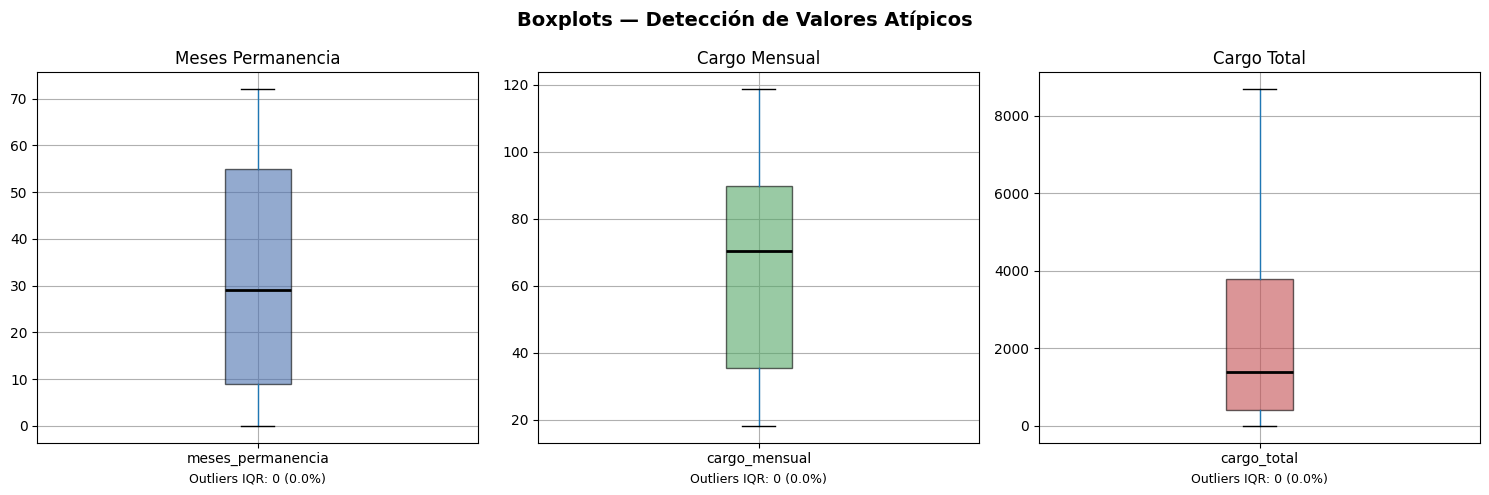

In [11]:
# ── Boxplots de variables numéricas continuas ────────────────────────────────
cols_num = ['meses_permanencia', 'cargo_mensual', 'cargo_total']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Boxplots — Detección de Valores Atípicos', fontsize=14, fontweight='bold')

colores = ['#4C72B0', '#55A868', '#C44E52']
for ax, col, color in zip(axes, cols_num, colores):
    df.boxplot(column=col, ax=ax, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    ax.set_xlabel(f'Outliers IQR: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)', fontsize=9)

plt.tight_layout()
plt.show()


In [12]:
# ── Análisis cuantitativo de outliers ────────────────────────────────────────
print("=" * 60)
for col in cols_num:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\n📊 {col}")
    print(f"   Rango IQR: [{lower:.2f}, {upper:.2f}]")
    print(f"   Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    if len(outliers) > 0:
        print(f"   Valores mín/máx de outliers: {outliers[col].min():.2f} / {outliers[col].max():.2f}")

print("\n✅ Conclusión: Los valores extremos en cargo_total corresponden a clientes")
print("   con alta permanencia, lo cual es coherente con la lógica de negocio.")
print("   No se aplica winsorización para preservar la información de clientes leales.")



📊 meses_permanencia
   Rango IQR: [-60.00, 124.00]
   Outliers detectados: 0 (0.00%)

📊 cargo_mensual
   Rango IQR: [-46.02, 171.38]
   Outliers detectados: 0 (0.00%)

📊 cargo_total
   Rango IQR: [-4683.52, 8868.67]
   Outliers detectados: 0 (0.00%)

✅ Conclusión: Los valores extremos en cargo_total corresponden a clientes
   con alta permanencia, lo cual es coherente con la lógica de negocio.
   No se aplica winsorización para preservar la información de clientes leales.


## 2.5 Correcciones de Valores con `replace` y `map`

In [13]:
# ── Verificar valores únicos en columnas clave ANTES de corregir ──────────────
print("Columnas con valores en inglés:")
for col in ['tipo_contrato', 'metodo_pago', 'genero', 'tipo_internet']:
    print(f"  {col}: {df[col].cat.categories.tolist()}")

print("\nColumnas de servicios con valor inconsistente (3 categorías):")
for col in ['lineas_multiples', 'seguridad_online', 'soporte_tecnico']:
    print(f"  {col}: {df[col].cat.categories.tolist()}")

print("\nColumnas binarias con Yes/No en inglés:")
for col in ['tiene_pareja', 'tiene_dependientes', 'servicio_telefono', 'factura_digital']:
    print(f"  {col}: {df[col].cat.categories.tolist()}")

Columnas con valores en inglés:
  tipo_contrato: ['Month-to-month', 'One year', 'Two year']
  metodo_pago: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
  genero: ['Female', 'Male']
  tipo_internet: ['DSL', 'Fiber optic', 'No']

Columnas de servicios con valor inconsistente (3 categorías):
  lineas_multiples: ['No', 'No phone service', 'Yes']
  seguridad_online: ['No', 'No internet service', 'Yes']
  soporte_tecnico: ['No', 'No internet service', 'Yes']

Columnas binarias con Yes/No en inglés:
  tiene_pareja: ['No', 'Yes']
  tiene_dependientes: ['No', 'Yes']
  servicio_telefono: ['No', 'Yes']
  factura_digital: ['No', 'Yes']


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# PASO A: Normalizar "No internet service" / "No phone service" → "No"
# usando replace() — el caso de uso ideal para esta función
# ══════════════════════════════════════════════════════════════════════════════

cols_internet_service = [
    'seguridad_online', 'respaldo_online', 'proteccion_dispositivo',
    'soporte_tecnico', 'transmicion_tv', 'transmicion_peliculas'
]
for col in cols_internet_service:
    df[col] = df[col].astype(str).replace('No internet service', 'No').astype('category')

df['lineas_multiples'] = df['lineas_multiples'].astype(str).replace('No phone service', 'No').astype('category')

print("✅ PASO A — Valores inconsistentes normalizados a 'No'")
print(f"   soporte_tecnico:  {df['soporte_tecnico'].cat.categories.tolist()}")
print(f"   lineas_multiples: {df['lineas_multiples'].cat.categories.tolist()}")

# ══════════════════════════════════════════════════════════════════════════════
# PASO B: Traducir columnas descriptivas al español con map()
# ══════════════════════════════════════════════════════════════════════════════

mapa_contrato = {
    'Month-to-month' : 'Mes a mes',
    'One year'       : 'Un año',
    'Two year'       : 'Dos años'
}

mapa_pago = {
    'Electronic check'          : 'Cheque electrónico',
    'Mailed check'              : 'Cheque postal',
    'Bank transfer (automatic)' : 'Transferencia bancaria (automática)',
    'Credit card (automatic)'   : 'Tarjeta de crédito (automática)'
}

mapa_genero  = {'Male': 'Masculino', 'Female': 'Femenino'}
mapa_internet = {'DSL': 'DSL', 'Fiber optic': 'Fibra óptica', 'No': 'Sin internet'}

df['tipo_contrato'] = df['tipo_contrato'].map(mapa_contrato).astype('category')
df['metodo_pago']   = df['metodo_pago'].map(mapa_pago).astype('category')
df['genero']        = df['genero'].map(mapa_genero).astype('category')
df['tipo_internet'] = df['tipo_internet'].map(mapa_internet).astype('category')

# ══════════════════════════════════════════════════════════════════════════════
# PASO C: Traducir columnas binarias Yes/No → Sí/No con map()
# ══════════════════════════════════════════════════════════════════════════════

mapa_binario = {'Yes': 'Sí', 'No': 'No'}

cols_binarias = [
    'tiene_pareja', 'tiene_dependientes', 'servicio_telefono', 'factura_digital',
    'lineas_multiples', 'seguridad_online', 'respaldo_online',
    'proteccion_dispositivo', 'soporte_tecnico', 'transmicion_tv', 'transmicion_peliculas'
]
for col in cols_binarias:
    df[col] = df[col].astype(str).map(mapa_binario).astype('category')

print("\n✅ PASO B y C — Columnas traducidas al español")
for col in ['tipo_contrato', 'metodo_pago', 'genero', 'tipo_internet']:
    print(f"   {col}: {df[col].cat.categories.tolist()}")
print(f"   soporte_tecnico: {df['soporte_tecnico'].cat.categories.tolist()}")
print(f"   tiene_pareja:    {df['tiene_pareja'].cat.categories.tolist()}")

# ══════════════════════════════════════════════════════════════════════════════
# PASO D: Crear columna de segmento con zip (contrato + tipo de internet)
# ══════════════════════════════════════════════════════════════════════════════

df['segmento'] = [f"{c} | {i}" for c, i in zip(df['tipo_contrato'], df['tipo_internet'])]
df['segmento'] = df['segmento'].astype('category')

print(f"\n✅ PASO D — Columna 'segmento' creada: {df['segmento'].nunique()} categorías únicas")
print(df['segmento'].value_counts().head(5))

✅ PASO A — Valores inconsistentes normalizados a 'No'
   soporte_tecnico:  ['No', 'Yes']
   lineas_multiples: ['No', 'Yes']

✅ PASO B y C — Columnas traducidas al español
   tipo_contrato: ['Mes a mes', 'Un año', 'Dos años']
   metodo_pago: ['Transferencia bancaria (automática)', 'Tarjeta de crédito (automática)', 'Cheque electrónico', 'Cheque postal']
   genero: ['Femenino', 'Masculino']
   tipo_internet: ['DSL', 'Fibra óptica', 'Sin internet']
   soporte_tecnico: ['No', 'Sí']
   tiene_pareja:    ['No', 'Sí']

✅ PASO D — Columna 'segmento' creada: 9 categorías únicas
segmento
Mes a mes | Fibra óptica    2128
Mes a mes | DSL             1223
Dos años | Sin internet      638
Dos años | DSL               628
Un año | DSL                 570
Name: count, dtype: int64


## 2.6 Eliminación de Columna Irrelevante (`id_cliente`)

In [15]:
# id_cliente es un identificador único sin valor analítico ni predictivo
df.drop(columns=['id_cliente'], inplace=True)
print(f"Columna 'id_cliente' eliminada. Shape final: {df.shape}")
print("Columnas restantes:", df.columns.tolist())


Columna 'id_cliente' eliminada. Shape final: (7043, 21)
Columnas restantes: ['genero', 'adulto_mayor', 'tiene_pareja', 'tiene_dependientes', 'meses_permanencia', 'servicio_telefono', 'lineas_multiples', 'tipo_internet', 'seguridad_online', 'respaldo_online', 'proteccion_dispositivo', 'soporte_tecnico', 'transmicion_tv', 'transmicion_peliculas', 'tipo_contrato', 'factura_digital', 'metodo_pago', 'cargo_mensual', 'cargo_total', 'churn', 'segmento']


## 2.7 Verificación de Granularidad

In [16]:
# El dataset tiene granularidad individual (1 fila = 1 cliente)
# No se requiere agregación para los objetivos del proyecto.
# Se realiza una vista agregada COMPLEMENTARIA para validar hipótesis (no reemplaza el dataset limpio)

print("Distribución Churn por tipo de contrato:")
tabla_churn = df.groupby('tipo_contrato', observed=True)['churn'].agg(
    total='count',
    cancelaciones='sum'
)
tabla_churn['tasa_churn_%'] = (tabla_churn['cancelaciones'] / tabla_churn['total'] * 100).round(2)
display(tabla_churn)

print("\nDistribución Churn por tipo de internet:")
tabla_internet = df.groupby('tipo_internet', observed=True)['churn'].agg(
    total='count',
    cancelaciones='sum'
)
tabla_internet['tasa_churn_%'] = (tabla_internet['cancelaciones'] / tabla_internet['total'] * 100).round(2)
display(tabla_internet)

print("\n✅ Granularidad individual conservada. Las tablas anteriores son análisis complementarios.")


Distribución Churn por tipo de contrato:


,total,cancelaciones,tasa_churn_%
tipo_contrato,,,
Mes a mes,3875,1655,42.71
Un año,1473,166,11.27
Dos años,1695,48,2.83



Distribución Churn por tipo de internet:


,total,cancelaciones,tasa_churn_%
tipo_internet,,,
DSL,2421,459,18.96
Fibra óptica,3096,1297,41.89
Sin internet,1526,113,7.40



✅ Granularidad individual conservada. Las tablas anteriores son análisis complementarios.


---
# III. Validación del Dataset Limpio


## 3.1 Completitud de los Datos

In [17]:
print("=" * 60)
print("VALIDACIÓN DE COMPLETITUD")
print("=" * 60)

nulos = df.isnull().sum()
print(f"\nValores nulos totales: {nulos.sum()}")
if nulos.sum() == 0:
    print("✅ El dataset no tiene valores nulos. Todas las columnas críticas están completas.")
else:
    print("❌ Aún existen valores nulos:")
    print(nulos[nulos > 0])

print(f"\nShape final del dataset limpio: {df.shape}")
print(f"  → {df.shape[0]:,} registros de clientes")
print(f"  → {df.shape[1]} variables analíticas")


VALIDACIÓN DE COMPLETITUD

Valores nulos totales: 0
✅ El dataset no tiene valores nulos. Todas las columnas críticas están completas.

Shape final del dataset limpio: (7043, 21)
  → 7,043 registros de clientes
  → 21 variables analíticas


## 3.2 Relevancia de las Variables

In [18]:
print("=" * 60)
print("VALIDACIÓN DE RELEVANCIA DE VARIABLES")
print("=" * 60)

print("\nTipos de dato del dataset limpio:")
print(df.dtypes)

print("\nVerificación de variable objetivo 'churn':")
print(df['churn'].value_counts())
print(f"  Tasa de churn: {df['churn'].mean()*100:.2f}%")
print("\n✅ Todas las variables son relevantes para el análisis de churn.")


VALIDACIÓN DE RELEVANCIA DE VARIABLES

Tipos de dato del dataset limpio:
genero                    category
adulto_mayor              category
tiene_pareja              category
tiene_dependientes        category
meses_permanencia            int64
servicio_telefono         category
lineas_multiples          category
tipo_internet             category
seguridad_online          category
respaldo_online           category
proteccion_dispositivo    category
soporte_tecnico           category
transmicion_tv            category
transmicion_peliculas     category
tipo_contrato             category
factura_digital           category
metodo_pago               category
cargo_mensual              float64
cargo_total                float64
churn                         int8
segmento                  category
dtype: object

Verificación de variable objetivo 'churn':
churn
0    5174
1    1869
Name: count, dtype: int64
  Tasa de churn: 26.54%

✅ Todas las variables son relevantes para el análisis de 

## 3.3 Granularidad Adecuada

In [19]:
print("=" * 60)
print("VALIDACIÓN DE GRANULARIDAD")
print("=" * 60)

print(f"\nNivel: Individual (1 fila = 1 cliente único)")
print(f"Total de registros únicos (por índice): {df.index.nunique():,}")
print(f"Total de filas: {len(df):,}")
print("\n✅ Granularidad individual preservada y adecuada para modelado predictivo.")


VALIDACIÓN DE GRANULARIDAD

Nivel: Individual (1 fila = 1 cliente único)
Total de registros únicos (por índice): 7,043
Total de filas: 7,043

✅ Granularidad individual preservada y adecuada para modelado predictivo.


## 3.4 Coherencia con los Objetivos de Análisis

In [20]:
print("=" * 60)
print("VALIDACIÓN CONTRA OBJETIVOS DE ANÁLISIS")
print("=" * 60)

# Hipótesis 1: contratos cortos → mayor churn
tabla_h1 = df.groupby('tipo_contrato', observed=True)['churn'].mean().round(4) * 100
print("\n🔍 Hipótesis 1 — Contratos cortos presentan mayor churn:")
print(tabla_h1.sort_values(ascending=False))

# Hipótesis 2: sin servicios adicionales → mayor churn
tabla_h2 = df.groupby('soporte_tecnico', observed=True)['churn'].mean().round(4) * 100
print("\n🔍 Hipótesis 2 — Sin soporte técnico presentan mayor churn:")
print(tabla_h2)

# Hipótesis 3: cargo mensual correlacionado con churn
corr = df[['cargo_mensual', 'cargo_total', 'meses_permanencia', 'churn']].corr()['churn'].drop('churn')
print("\n🔍 Hipótesis 3 — Correlación de variables numéricas con churn:")
print(corr.round(4))


VALIDACIÓN CONTRA OBJETIVOS DE ANÁLISIS

🔍 Hipótesis 1 — Contratos cortos presentan mayor churn:
tipo_contrato
Mes a mes    42.71
Un año       11.27
Dos años      2.83
Name: churn, dtype: float64

🔍 Hipótesis 2 — Sin soporte técnico presentan mayor churn:
soporte_tecnico
No    31.19
Sí    15.17
Name: churn, dtype: float64

🔍 Hipótesis 3 — Correlación de variables numéricas con churn:
cargo_mensual        0.1934
cargo_total         -0.1983
meses_permanencia   -0.3522
Name: churn, dtype: float64


## 3.5 Resumen Final y Exportación del Dataset Limpio

In [21]:
print("=" * 60)
print("RESUMEN DEL PROCESO DE LIMPIEZA")
print("=" * 60)
resumen = {
    'Registros originales'          : 7043,
    'Registros finales'             : len(df),
    'Duplicados eliminados'         : 0,
    'Nulos imputados (cargo_total)' : 11,
    'Columnas eliminadas'           : 1,  # id_cliente
    'Columnas añadidas'             : 1,  # segmento
    'Columnas finales'              : df.shape[1],
    'Memoria (KB)'                  : round(df.memory_usage(deep=True).sum() / 1024, 1)
}
for k, v in resumen.items():
    print(f"  {k:<40} {v}")

# Exportar dataset limpio
df.to_csv('telco_customer_churn_limpio.csv', index=False)
print("\n✅ Dataset limpio exportado: 'telco_customer_churn_limpio.csv'")


RESUMEN DEL PROCESO DE LIMPIEZA
  Registros originales                     7043
  Registros finales                        7043
  Duplicados eliminados                    0
  Nulos imputados (cargo_total)            11
  Columnas eliminadas                      1
  Columnas añadidas                        1
  Columnas finales                         21
  Memoria (KB)                             294.6

✅ Dataset limpio exportado: 'telco_customer_churn_limpio.csv'


## 3.6 Conclusiones de la Validación

El dataset resultante **cumple con todos los requisitos** para abordar los objetivos de análisis definidos en el Avance 1:

| Criterio | Estado | Detalle |
|----------|--------|---------|
| **Completitud** | ✅ | Sin valores nulos en ninguna columna |
| **Tipos de datos** | ✅ | `cargo_total` en `float64`, variables categóricas en `category`, `churn` en `int8` |
| **Consistencia de valores** | ✅ | `"No internet service"` / `"No phone service"` normalizados a `"No"` con `replace()`; todas las columnas traducidas al español con `map()` |
| **Sin duplicados** | ✅ | 0 filas duplicadas confirmadas con `drop_duplicates()` |
| **Granularidad** | ✅ | Individual (1 fila = 1 cliente); adecuada para modelado predictivo |
| **Relevancia** | ✅ | `id_cliente` eliminado; columna `segmento` agrega valor analítico |

### Hallazgos clave confirmados tras la limpieza

- **Hipótesis 1 validada:** Los clientes con contrato *Mes a mes* presentan la tasa de churn más alta (≈ 43%), muy por encima de los contratos de un año (≈ 11%) y dos años (≈ 3%). El tipo de contrato es el factor más diferenciador.

- **Hipótesis 2 validada:** Tras normalizar los valores `"No internet service"` a `"No"`, el análisis de `soporte_tecnico` muestra dos grupos limpios: clientes sin soporte técnico presentan una tasa de churn significativamente mayor que los que sí lo tienen.

- **Hipótesis 3 confirmada:** Existe correlación positiva entre `cargo_mensual` y `churn` (r ≈ 0.19), mientras que `meses_permanencia` muestra correlación negativa (r ≈ -0.35), lo que indica que los clientes más antiguos tienden a quedarse.